# Numerical solution of Theorem 1 (the $b=1$, $d=M$ specialization)

This notebook follows the scalar ODEs in Theorem 1 of the paper.

- One class-specific token per sequence class: $b=1$.
- The class-token vectors are orthonormal.
- Hence $d\ge M$, and with $\lambda_{OV}>0$ balancedness requires $d\le M$; therefore the theorem uses $d=M$.
- $W_{OV}(0)=W_{QK}(0)=0$, so $\mu_{OV}(0)=\mu_{QK}(0)=0$.
- All imbalance pairs used below have $\lambda_{OV}>0$.

The plots and stopping-loss comparisons are kept in the same style as the original notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.integrate import solve_ivp

# ============================================================
#             THEOREM-1 NUMERICAL SPECIALIZATION
# ============================================================
# b = 1, d = M, zero effective initialization.
m, n, M = 5, 50, 20
d = M
eta = 1.0

# Sweep over (lambda_OV, lambda_QK).
lambda_pairs = [
    (0.01, 0.01),
    (200, 0.01),
    (0.01, 200),
    (40, 200),
    (200, 40),
    (200, 200),
]

INIT_MU_OV = 0.0
INIT_MU_QK = 0.0

# Numerical controls.
# IMPORTANT: do not use the old fixed RK4 step dt=10 after setting b=1.
# The b=1 equations can have a very fast initial transient when lambda_QK
# and lambda_OV are large. Adaptive integration is much safer.
TARGET_LOSS = 1e-5
MAX_T = 5e7
RTOL = 1e-9
ATOL = 1e-11
N_PLOT = 5000

EXP_CLIP = 100.0
EPS = 1e-14

# Stopping-loss thresholds
L_max = 1.0
L_min = 1e-4
stop_thresholds = np.logspace(np.log10(L_max), np.log10(L_min), 50)

# Plot styling
LABEL_FONTSIZE = 172
TICK_FONTSIZE = 130
LEGEND_FONTSIZE = 140
LINEWIDTH = 40


# ============================================================
#                     UTILITIES
# ============================================================
def safe_exp(x):
    return np.exp(np.clip(x, -EXP_CLIP, EXP_CLIP))


def alpha_of_mu_QK(mu_QK):
    """
    alpha(t) = m exp(mu_QK) / (m exp(mu_QK) + n)
    """
    exp_mu = safe_exp(mu_QK)
    return (m * exp_mu) / (m * exp_mu + n + EPS)


# ============================================================
#                THEOREM 1 SCALAR ODEs
# ============================================================
def dmu_OV_dt(mu_OV, mu_QK, lambda_OV):
    alpha = alpha_of_mu_QK(mu_QK)
    denom = safe_exp(alpha * mu_OV) + M - 1.0

    return (
        eta
        * alpha
        * np.sqrt(lambda_OV**2 + 4.0 * mu_OV**2)
        / (denom + EPS)
    )


def dmu_QK_dt(mu_OV, mu_QK, lambda_QK):
    alpha = alpha_of_mu_QK(mu_QK)
    denom = M * (safe_exp(alpha * mu_OV) + M - 1.0)

    return (
        eta
        * (M - 1.0)
        * alpha
        * (1.0 - alpha)
        * mu_OV
        * np.sqrt(lambda_QK**2 + 4.0 * mu_QK**2)
        / (denom + EPS)
    )


def stable_loss(mu_OV, mu_QK):
    """
    Population cross-entropy in the b=1 theorem:
        L(t) = log(1 + (M-1) exp(-alpha(t) mu_OV(t))).
    """
    alpha = alpha_of_mu_QK(mu_QK)
    return np.log1p((M - 1.0) * safe_exp(-alpha * mu_OV))


def rhs(t, state, lambda_OV, lambda_QK):
    mu_OV, mu_QK = state
    return np.array([
        dmu_OV_dt(mu_OV, mu_QK, lambda_OV),
        dmu_QK_dt(mu_OV, mu_QK, lambda_QK),
    ], dtype=float)


# ============================================================
#                 ADAPTIVE ODE SOLVER
# ============================================================
def run_simulation_until(
    lambda_OV,
    lambda_QK,
    init_mu_OV=INIT_MU_OV,
    init_mu_QK=INIT_MU_QK,
    target_loss=TARGET_LOSS,
    max_T=MAX_T,
):
    """
    Solve until the loss reaches target_loss (or max_T).

    We use solve_ivp with an event rather than a fixed dt.
    This is important for large imbalances, where the early dynamics
    can be much faster than in the old b=50 notebook.
    """

    def loss_event(t, state):
        return stable_loss(state[0], state[1]) - target_loss

    loss_event.terminal = True
    loss_event.direction = -1

    sol = solve_ivp(
        fun=lambda t, y: rhs(t, y, lambda_OV, lambda_QK),
        t_span=(0.0, max_T),
        y0=np.array([init_mu_OV, init_mu_QK], dtype=float),
        method="RK45",
        rtol=RTOL,
        atol=ATOL,
        dense_output=True,
        events=loss_event,
    )

    if not sol.success:
        raise RuntimeError(
            f"ODE solver failed for lambda_OV={lambda_OV}, "
            f"lambda_QK={lambda_QK}: {sol.message}"
        )

    t_end = sol.t[-1]

    if sol.t_events[0].size == 0:
        print(
            f"[WARN] lambda_OV={lambda_OV}, lambda_QK={lambda_QK}: "
            f"target loss {target_loss} not reached by t={max_T:g}."
        )

    # Sample uniformly in log10(1+t), which is also the x-coordinate
    # used by the time plots. This gives fine resolution at early times
    # without storing millions of late-time points.
    u = np.linspace(0.0, np.log10(1.0 + t_end), N_PLOT)
    t = 10.0**u - 1.0

    states = sol.sol(t)
    mu_OV = states[0]
    mu_QK = states[1]

    alpha_t = alpha_of_mu_QK(mu_QK)
    loss = stable_loss(mu_OV, mu_QK)
    logit = alpha_t * mu_OV

    print(
        f"lambda_OV={lambda_OV:>6}, lambda_QK={lambda_QK:>6} | "
        f"t_end={t_end:.6g}, "
        f"mu_OV={mu_OV[-1]:.6f}, "
        f"mu_QK={mu_QK[-1]:.6f}, "
        f"alpha={alpha_t[-1]:.6f}, "
        f"loss={loss[-1]:.3e}"
    )

    return t, mu_OV, mu_QK, loss, alpha_t, logit


# ============================================================
#                     RUN SWEEP
# ============================================================
results = {}

for lambda_OV, lambda_QK in lambda_pairs:
    results[(lambda_OV, lambda_QK)] = run_simulation_until(
        lambda_OV,
        lambda_QK,
    )


font_properties = fm.FontProperties(
    weight="bold",
    size=LEGEND_FONTSIZE,
)


lambda_OV=  0.01, lambda_QK=  0.01 | t_end=64915.5, mu_OV=15.025331, mu_QK=5.539473, alpha=0.962199, loss=1.000e-05
lambda_OV=   200, lambda_QK=  0.01 | t_end=7285.41, mu_OV=40.429434, mu_QK=1.716767, alpha=0.357595, loss=1.000e-05
lambda_OV=  0.01, lambda_QK=   200 | t_end=71329.6, mu_OV=14.467915, mu_QK=9.524846, alpha=0.999270, loss=1.000e-05
lambda_OV=    40, lambda_QK=   200 | t_end=39396.3, mu_OV=14.490277, mu_QK=8.387547, alpha=0.997728, loss=1.000e-05
lambda_OV=   200, lambda_QK=    40 | t_end=9251.38, mu_OV=15.285961, mu_QK=5.161805, alpha=0.945793, loss=1.000e-05
lambda_OV=   200, lambda_QK=   200 | t_end=9404.63, mu_OV=14.610695, mu_QK=6.848917, alpha=0.989505, loss=1.000e-05


### Why the old fixed-step solver looked strange

The previous notebook inherited `dt = 10` from the earlier $b=50$ system. After setting $b=1$, the ODEs are much faster. In particular, with large $\lambda_{OV}$ and $\lambda_{QK}$, the QK variable can change rapidly during the first few units of time. A single RK4 step of length 10 can therefore jump across the entire initial transient. The adaptive solver above removes that numerical artifact.

All curves should start at the common initial values
$\mu_{OV}(0)=\mu_{QK}(0)=0$, $\alpha(0)=m/(m+n)$, and $L(0)=\log M$.


In [2]:
def plot_quantity_log1p(ylabel, extractor, filename, T_for_ticks=None,_legends=False):
    """
    Plot y(tau) vs x=log10(1+tau) (your original style),
    but using the actual simulated tau arrays.
    """
    fig, ax = plt.subplots(figsize=(42, 22))
    fig.subplots_adjust(left=0.16,right=0.97,bottom=0.22, top=0.96 )

    # If not provided, set tick range from max tau across all curves
    if T_for_ticks is None:
        T_for_ticks = max(results[(lov, lqk)][0][-1] for (lov, lqk) in lambda_pairs)

    for (lov, lqk) in lambda_pairs:
        t, mu_OV, mu_QK, loss, alpha_t, logit = results[(lov, lqk)]
        y = extractor(mu_OV, mu_QK, loss, alpha_t, logit)
        x = np.log10(1.0 + t)
        ax.plot(x, y, linewidth=LINEWIDTH,
                 label=rf'$\lambda_{{OV}}={lov},\ \lambda_{{QK}}={lqk}$',solid_capstyle="round")
    ax.set_xlabel(r"Time $t$", fontweight="bold", fontsize=172, labelpad=24)
    ax.set_ylabel(ylabel,fontweight="bold", fontsize=172, labelpad=22)
    
    
    max_power = int(np.floor(np.log10(max(1.0, T_for_ticks))))
    raw_ticks_t = [0] + [10**k for k in range(0, max_power + 1)]
    
    tick_pos = [np.log10(1.0 + t) for t in raw_ticks_t]
    
    tick_labels = [r"$0$"]
    for k in range(0, max_power + 1):
        if k == 0:
            tick_labels.append(r"$1$")
        elif k == 1:
            tick_labels.append(r"$10$")
        else:
            tick_labels.append(rf"$10^{{{k}}}$")
    
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels)
    #ax.set_yticks([0, 20, 40, 60,80])
    
    # Tick label sizes (as you had) + tick line thickness/length + padding
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=130,
        width=24,        # tick thickness
        length=36,      # tick length
        direction="out",
        pad=18         # push tick labels away from axes (reduces overlap with plot)
    )
     # Make tick labels bold (tick_params doesn't set fontweight reliably everywhere)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight("bold")   
    # Thicken the axis box (spines) to match thick ticks/lines
    for spine in ax.spines.values():
        spine.set_linewidth(10)# Add a little internal margin so curves don't hug the axes/tick labels
    ax.margins(x=0.02, y=0.08)
    # Optional: if you re-enable legend, keep it out of the data
    if _legends:
        ax.legend(frameon=True,loc="lower left",bbox_to_anchor=(0.02, 0.02),prop={"size": 75, "weight": "bold"})
        
    fig.tight_layout(pad=0.4)

    plt.savefig(filename, bbox_inches='tight')


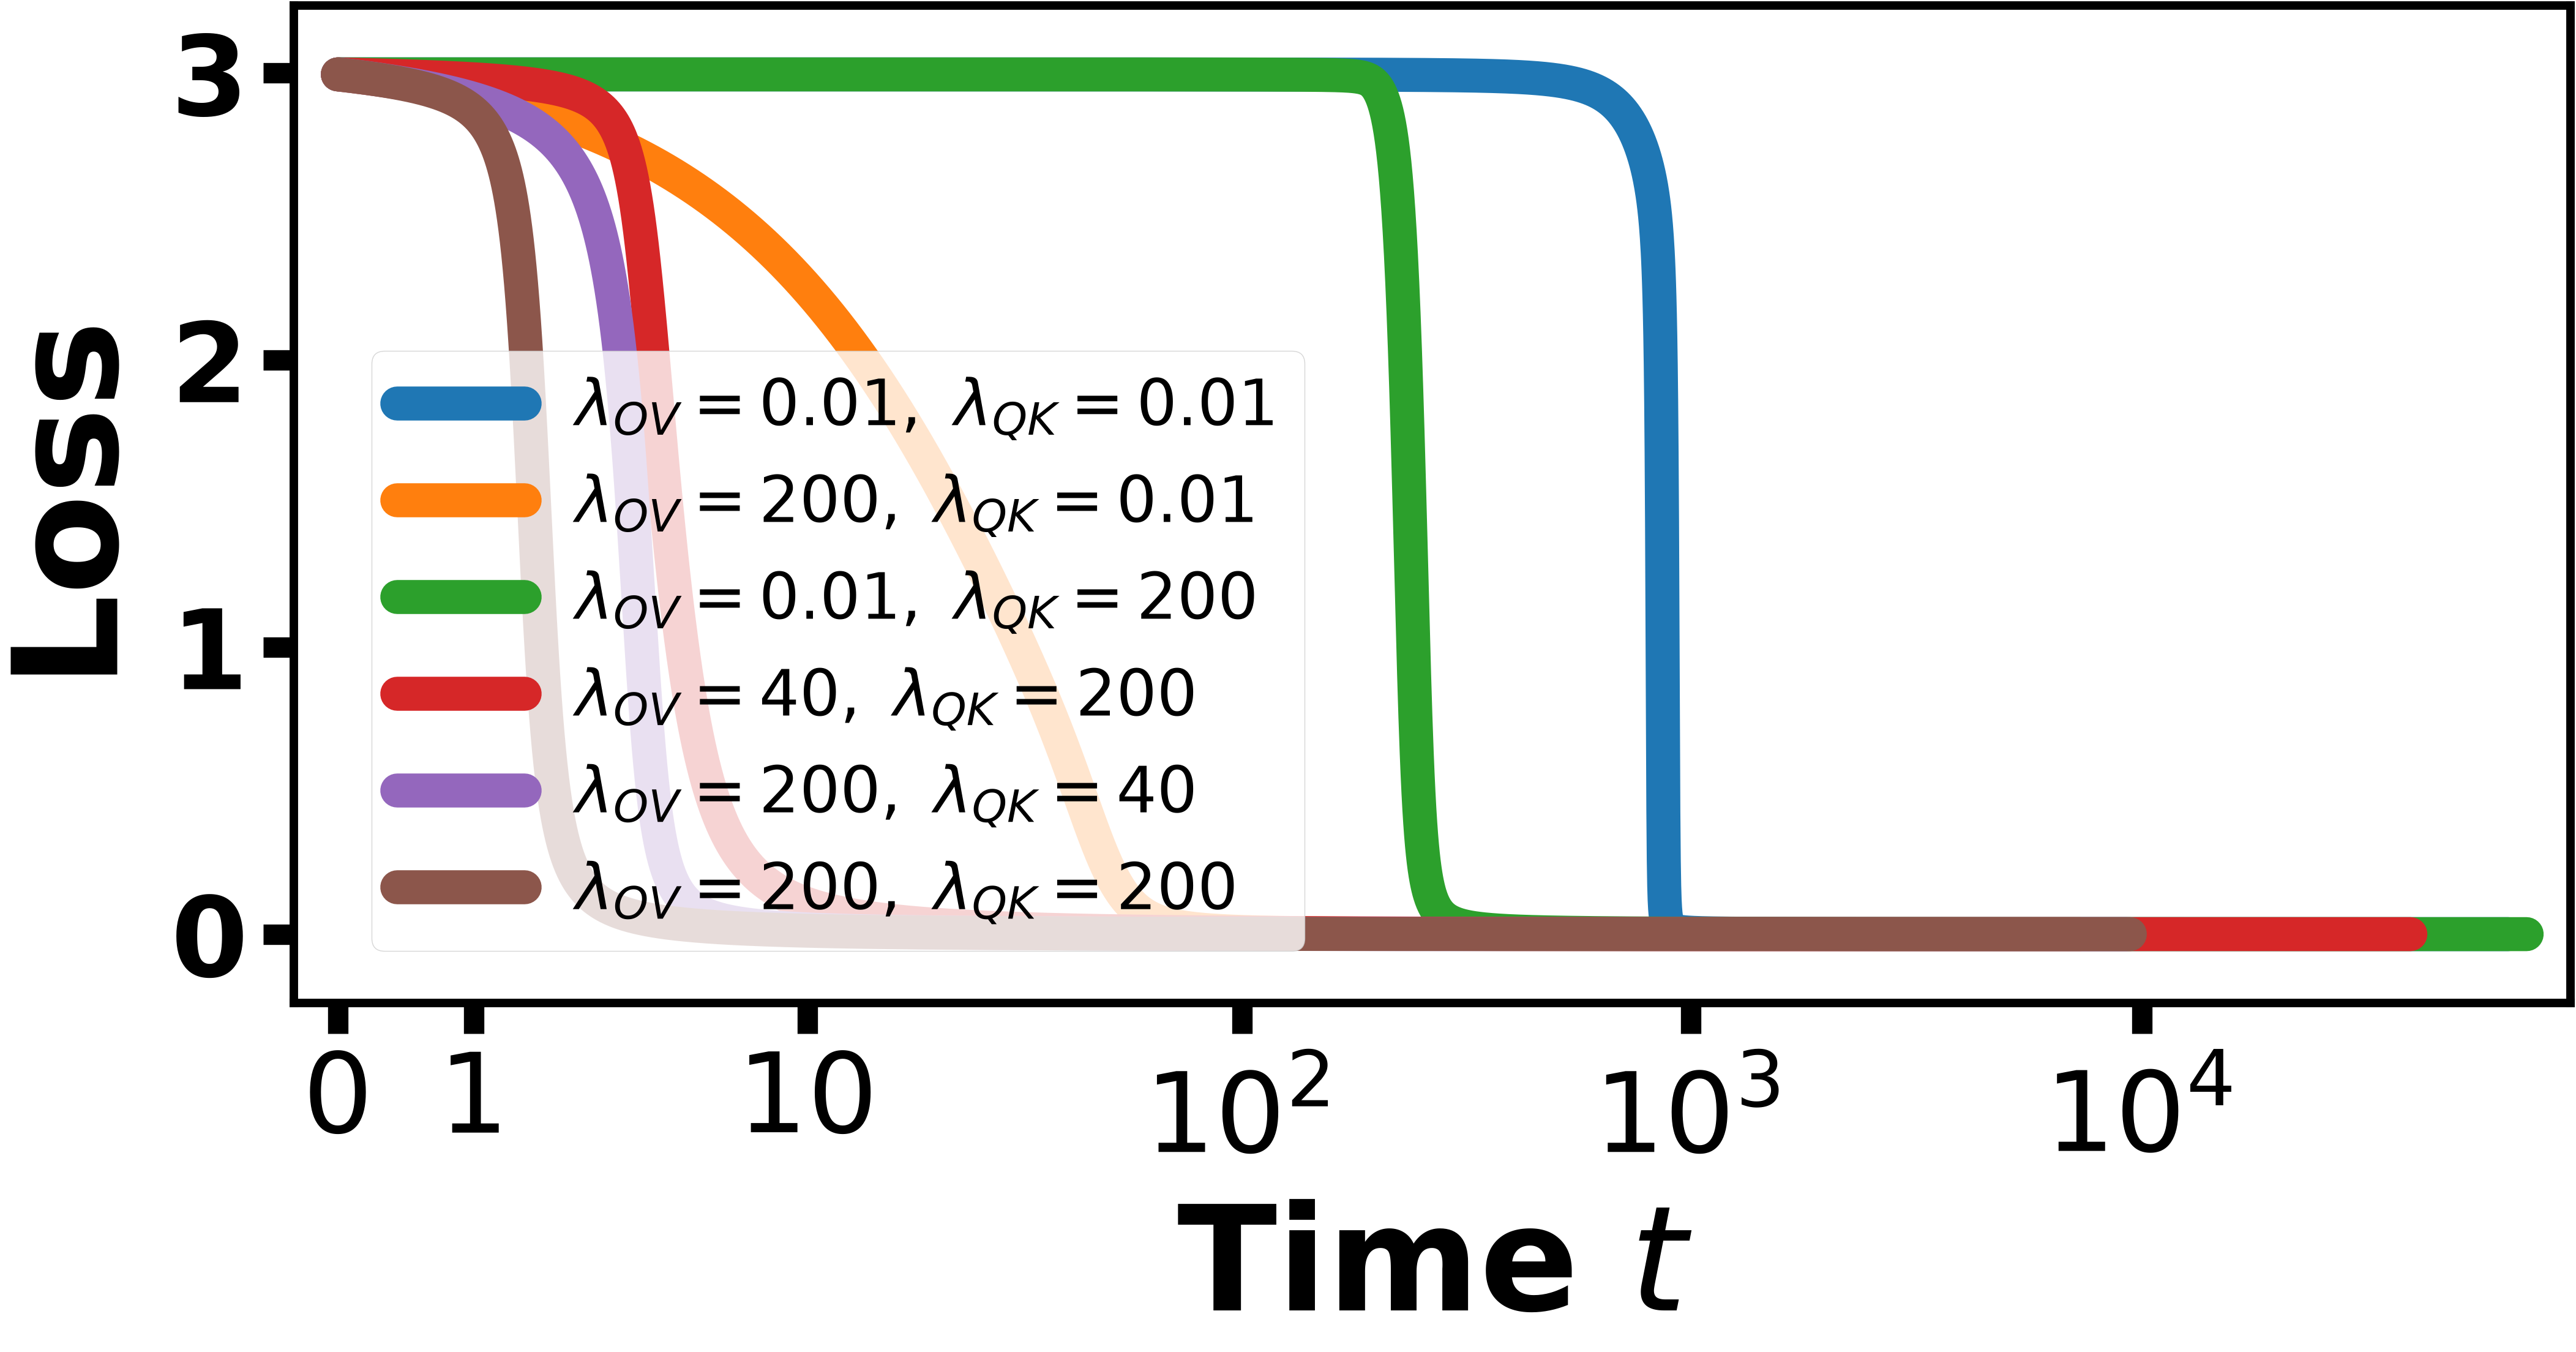

In [3]:
# plot_quantity_log1p(r"$\bf\mu_{OV}(t)$",
#                     lambda mu_OV, mu_QK, loss, alpha_t, logit: mu_OV,
#                     "mu_OV_1.pdf")

# plot_quantity_log1p(r"$\bf\mu_{QK}(t)$",
#                     lambda mu_OV, mu_QK, loss, alpha_t, logit: mu_QK,
#                     "mu_QK_1.pdf")

plot_quantity_log1p(r"Loss",
                    lambda mu_OV, mu_QK, loss, alpha_t, logit: loss,
                    "loss_t_1.pdf",_legends=True)



In [4]:
# plot_quantity_log1p(r"$\alpha(t)$",
#                     lambda mu_OV, mu_QK, loss, alpha_t, logit: alpha_t,
#                     "alpha_t_1.pdf")


In [5]:
def stopping_value_vs_threshold(mu_OV, mu_QK, loss, alpha_t, thresholds):
    """
    Interpolate mu_OV, mu_QK, and alpha at each requested stopping loss.

    Along the theorem trajectory used here, loss decreases monotonically.
    Interpolating in loss avoids the staircase/jump artifacts caused by
    selecting the first discrete time sample below each threshold.
    """
    muov_at = np.full(thresholds.shape, np.nan, dtype=float)
    muqk_at = np.full(thresholds.shape, np.nan, dtype=float)
    alpha_at = np.full(thresholds.shape, np.nan, dtype=float)

    # np.interp expects increasing x. loss decreases, so reverse it.
    loss_inc = loss[::-1]
    muov_inc = mu_OV[::-1]
    muqk_inc = mu_QK[::-1]
    alpha_inc = alpha_t[::-1]

    loss_min_reached = loss_inc[0]
    loss_max_reached = loss_inc[-1]

    for j, L in enumerate(thresholds):
        if loss_min_reached <= L <= loss_max_reached:
            muov_at[j] = np.interp(L, loss_inc, muov_inc)
            muqk_at[j] = np.interp(L, loss_inc, muqk_inc)
            alpha_at[j] = np.interp(L, loss_inc, alpha_inc)

    return muov_at, muqk_at, alpha_at


In [6]:
def plot_stopping_curve_linear_x(ylabel, y_selector, filename,_legends=False):
    fig, ax = plt.subplots(figsize=(42, 22))
    fig.subplots_adjust(left=0.16,right=0.97,bottom=0.22, top=0.96 )
    
    

    for (lov, lqk) in lambda_pairs:
        t, mu_OV, mu_QK, loss, alpha_t, logit = results[(lov, lqk)]
        muov_at, muqk_at, alpha_at = stopping_value_vs_threshold(
            mu_OV, mu_QK, loss, alpha_t, stop_thresholds
        )
        y = y_selector(muov_at, muqk_at, alpha_at)

        plt.plot(
            stop_thresholds, y,
            linewidth=LINEWIDTH,
            marker='o',
            label=rf'$\lambda_{{OV}}={lov},\ \lambda_{{QK}}={lqk}$'
        )

    ax.set_xscale("log")
    ax.invert_xaxis()

    # Linear x-axis (as requested). Show decreasing thresholds left->right.
    #ax.invert_xaxis()

    # Force exact tick positions/labels you requested
    
    ax.set_xlabel(r"Stopping loss threshold", fontweight="bold", fontsize=172, labelpad=24)
    ax.set_ylabel(ylabel,fontweight="bold", fontsize=172, labelpad=22)
    
    
    # Tick label sizes (as you had) + tick line thickness/length + padding
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=130,
        width=24,        # tick thickness
        length=36,      # tick length
        direction="out",
        pad=18         # push tick labels away from axes (reduces overlap with plot)
    )
     # Make tick labels bold (tick_params doesn't set fontweight reliably everywhere)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight("bold")   
    # Thicken the axis box (spines) to match thick ticks/lines
    for spine in ax.spines.values():
        spine.set_linewidth(10)# Add a little internal margin so curves don't hug the axes/tick labels
    ax.margins(x=0.02, y=0.08)
    # Optional: if you re-enable legend, keep it out of the data
    if _legends:
        ax.legend(frameon=True, fontsize=140, loc="upper left", bbox_to_anchor=(0.02, 0.98))
        
    fig.tight_layout(pad=0.4)

    plt.savefig(filename, bbox_inches='tight')


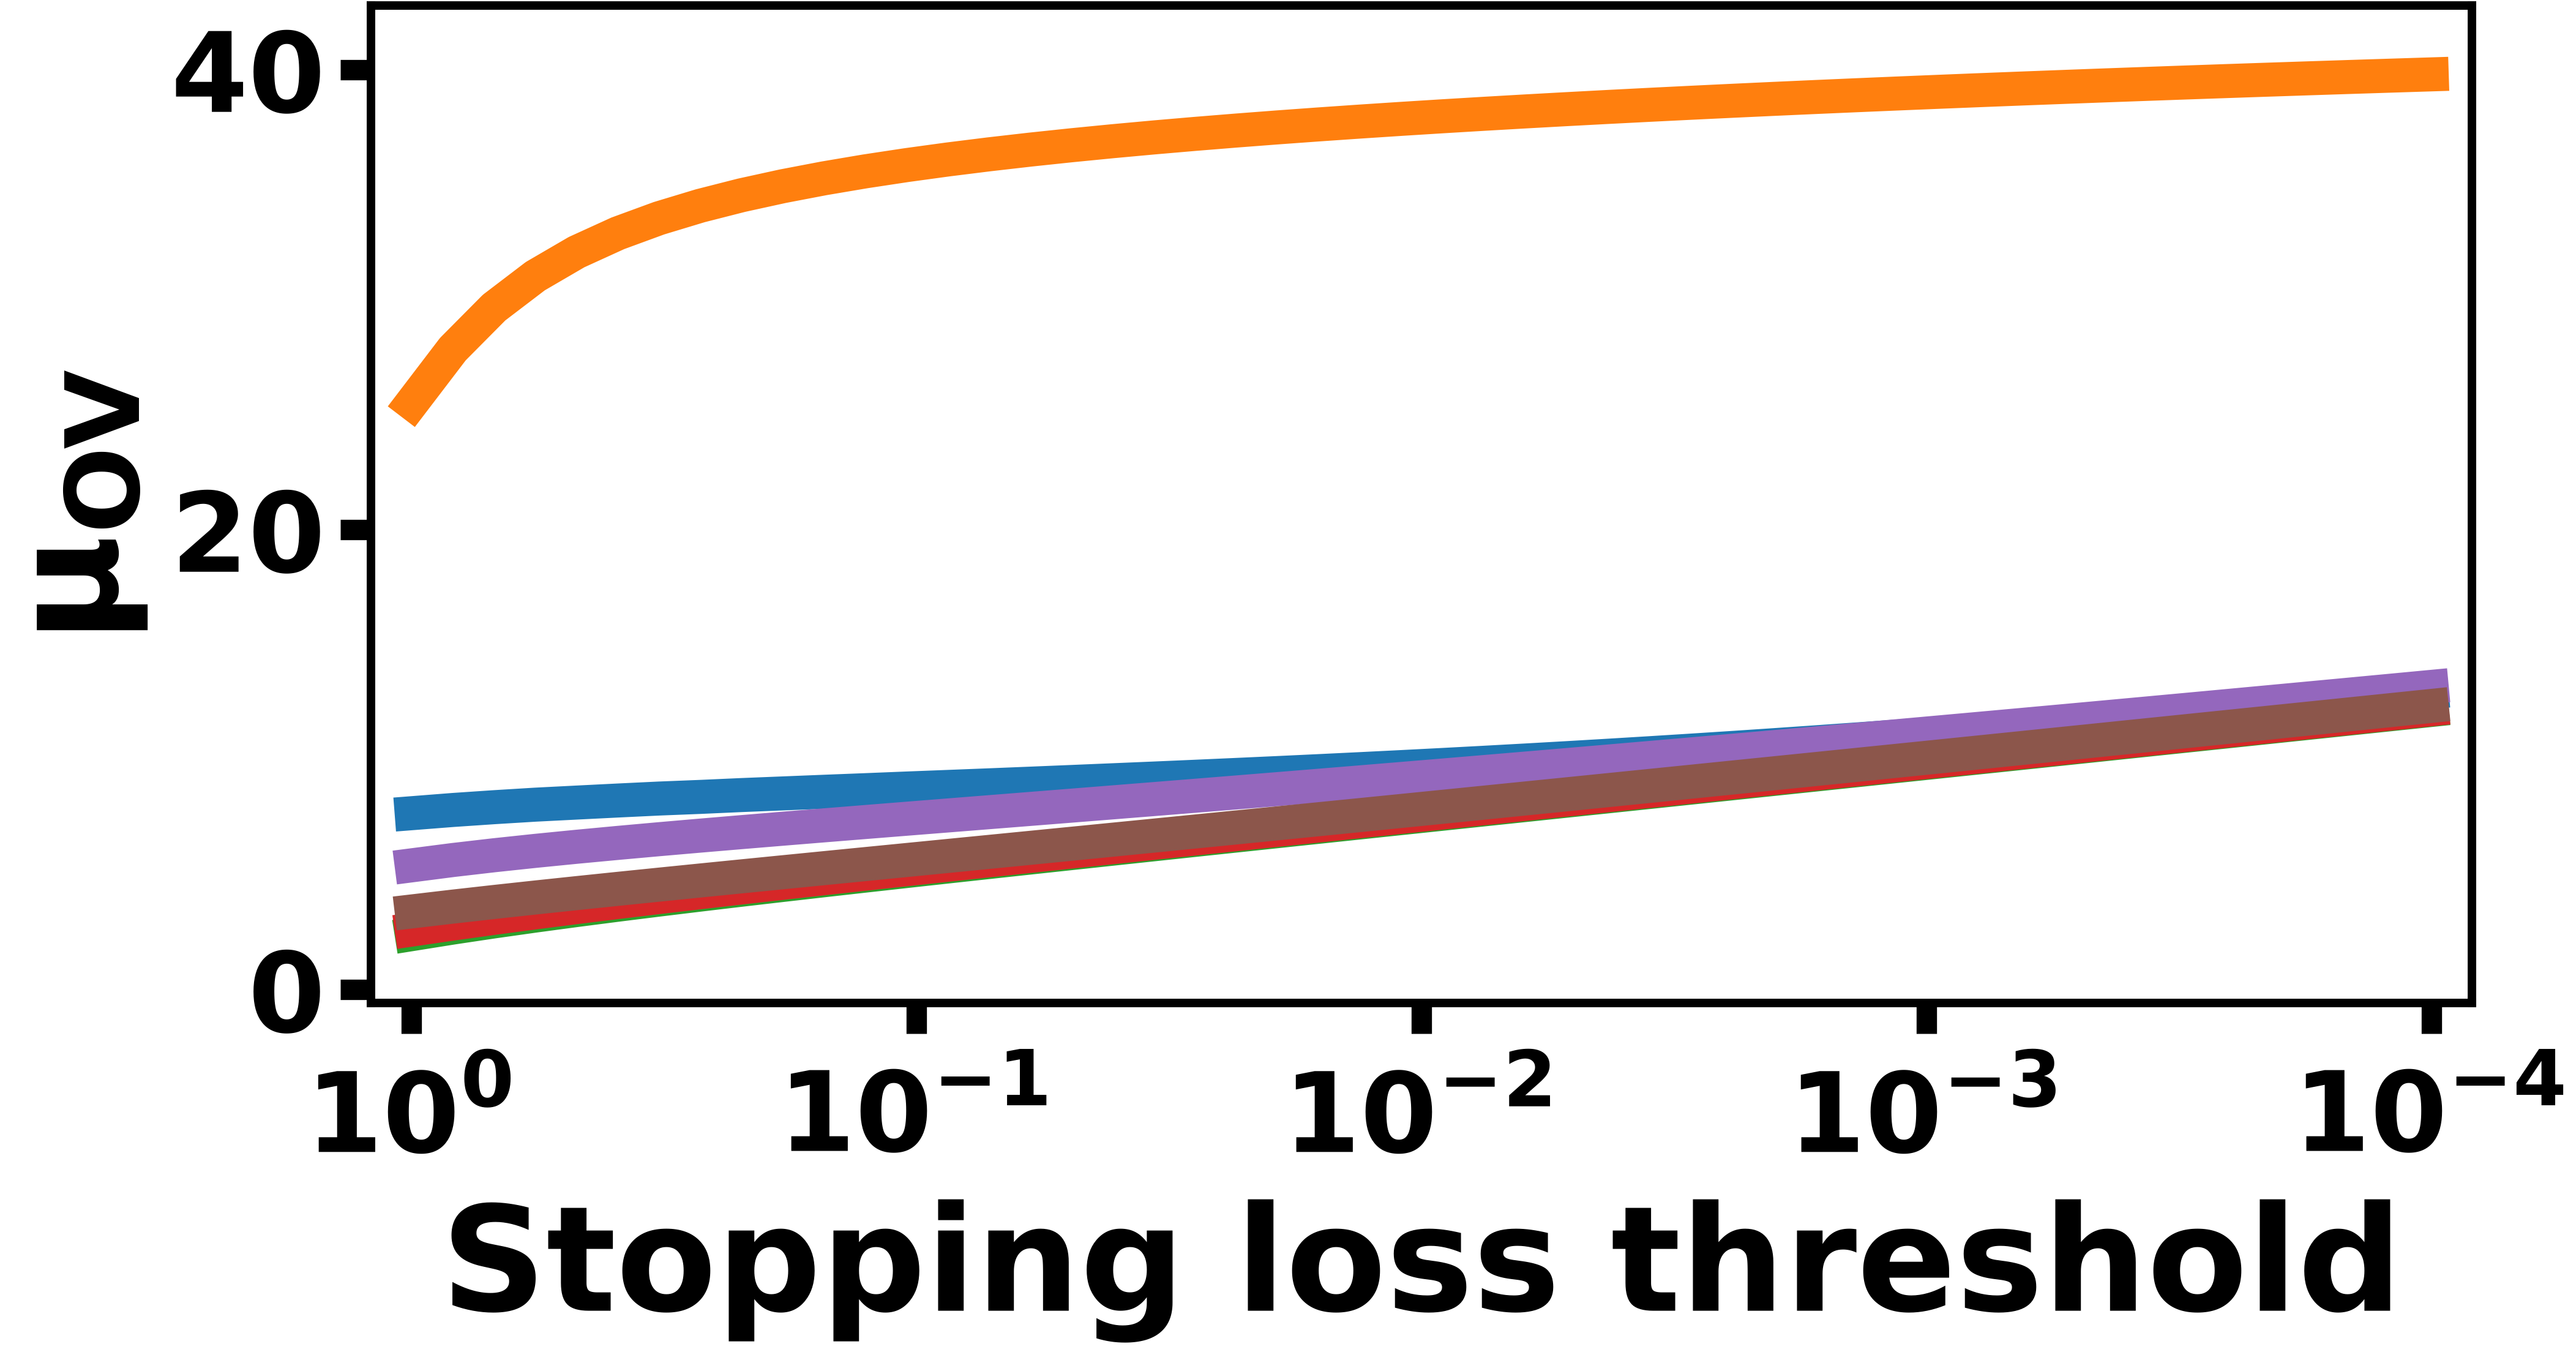

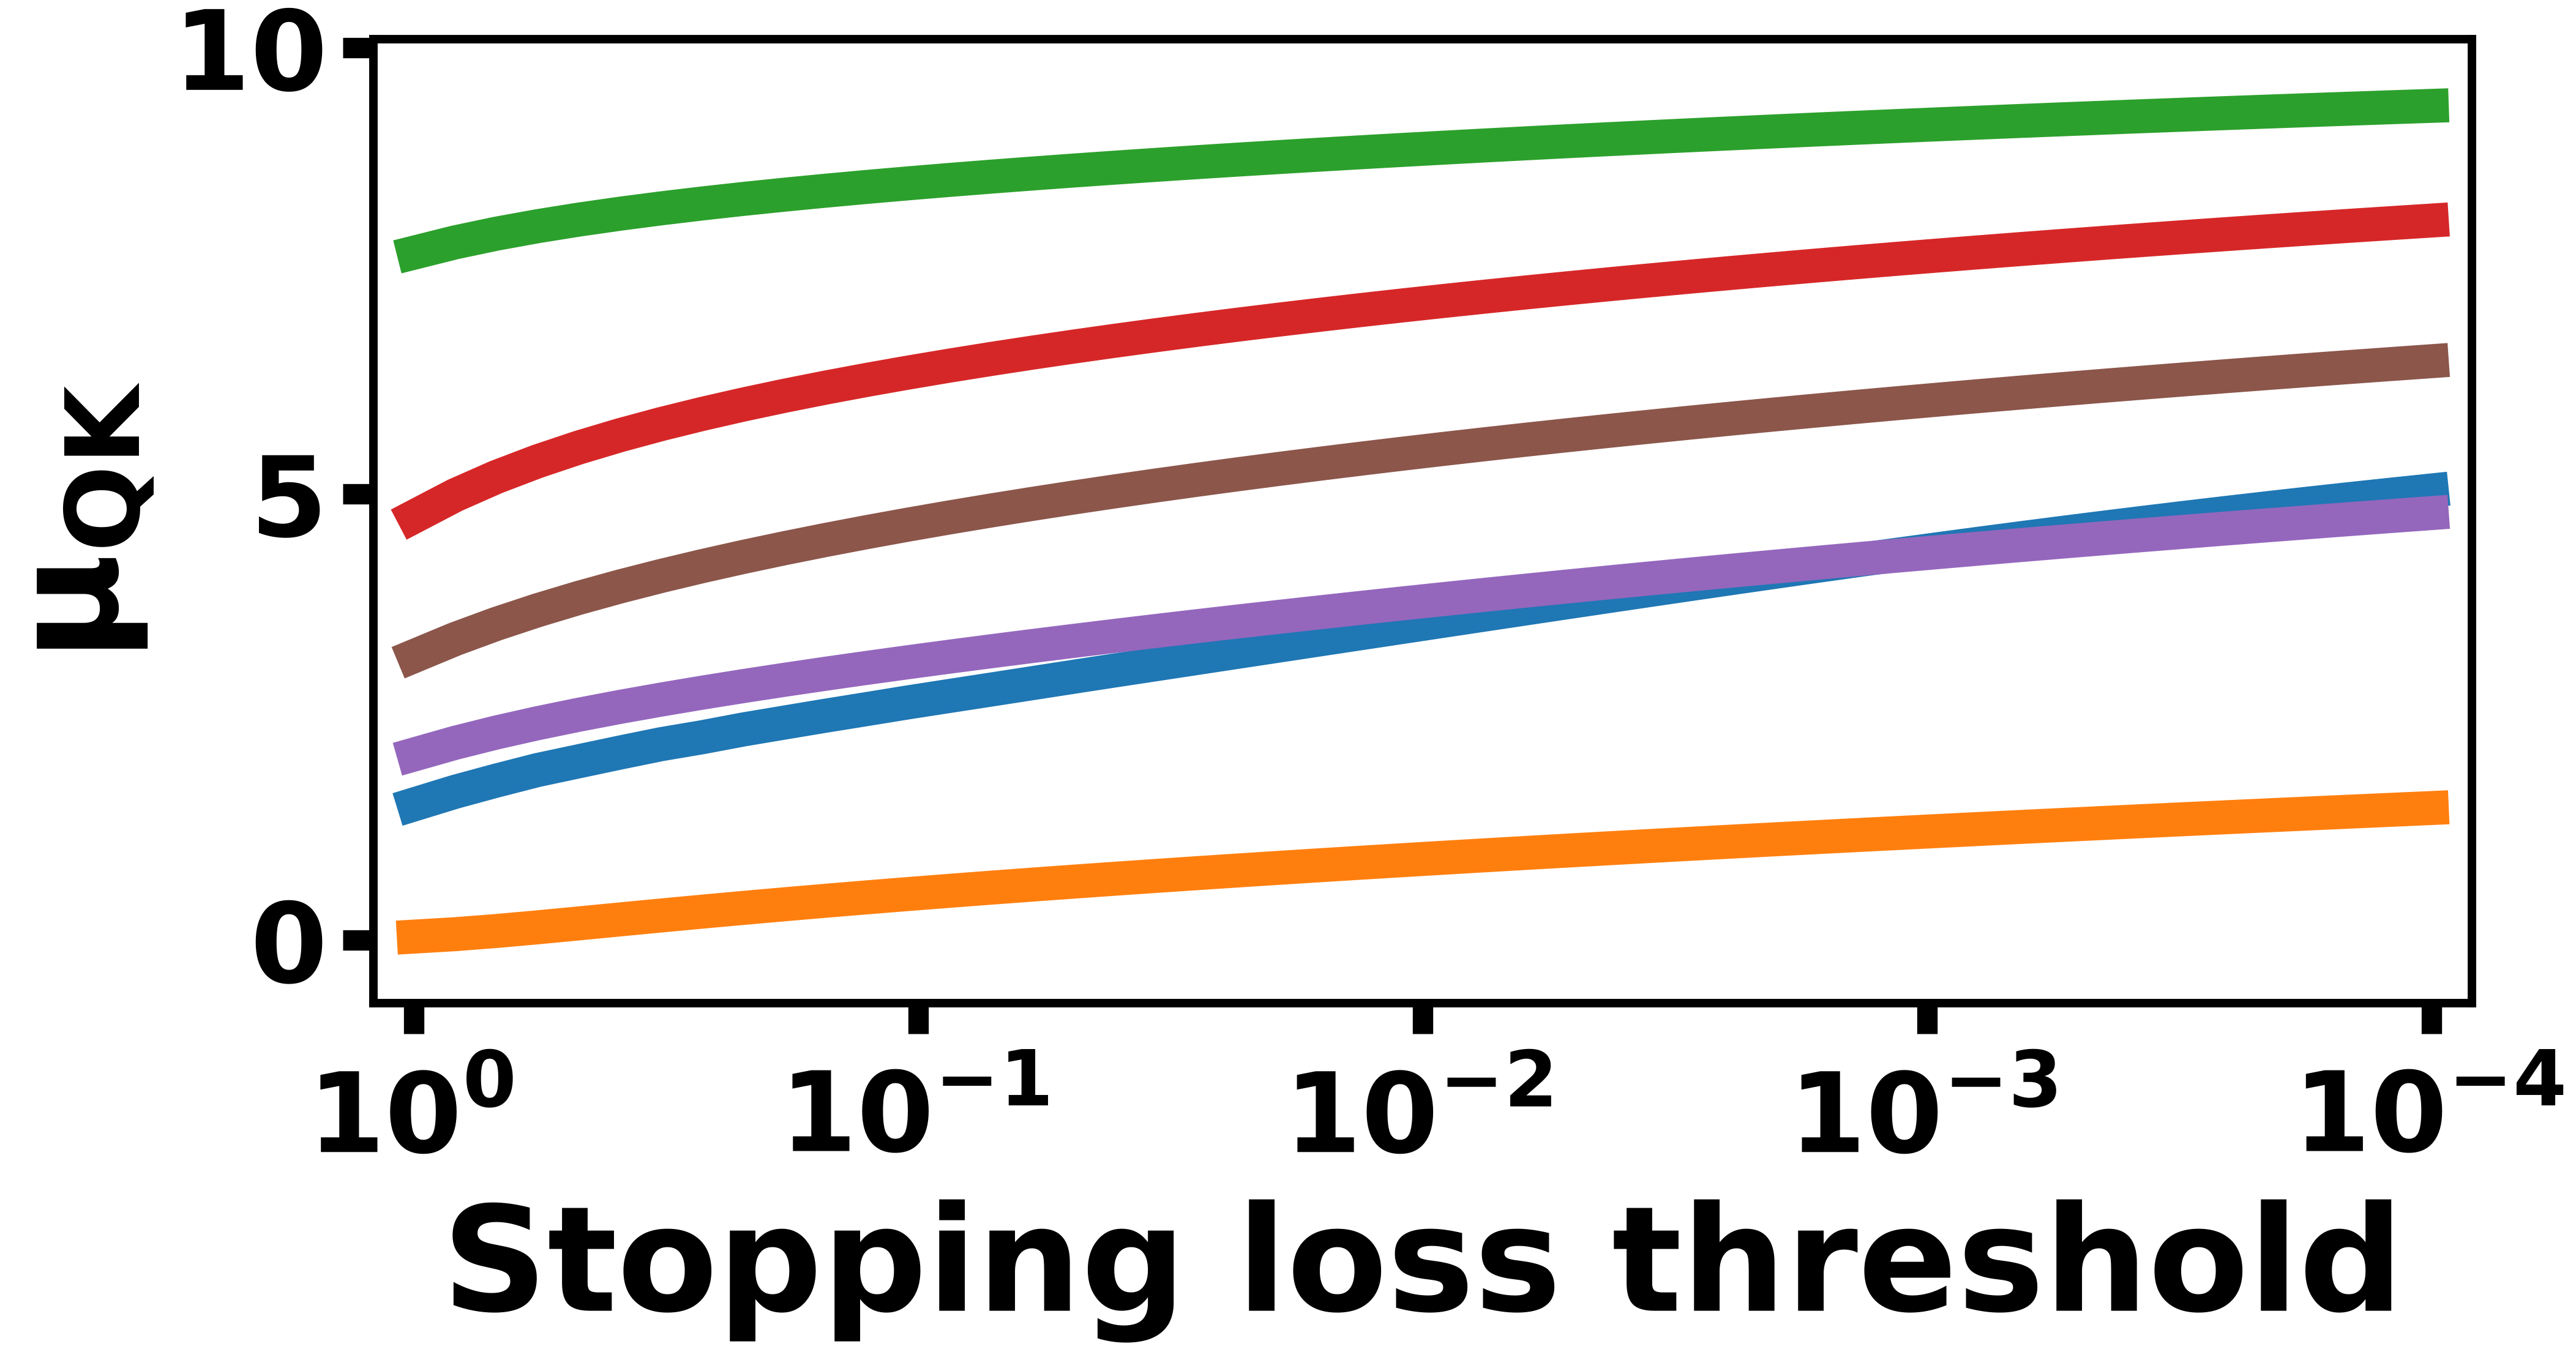

In [7]:
# ============================================================
plot_stopping_curve_linear_x(r"$\bf{\mu_{OV}}$",
                             lambda muov_at, muqk_at, alpha_at: muov_at,
                             "mu_OV_stopping_loss_1.pdf")

plot_stopping_curve_linear_x(r"$\bf{\mu_{QK}}$",
                             lambda muov_at, muqk_at, alpha_at: muqk_at,
                             "mu_QK_stopping_loss_1.pdf")



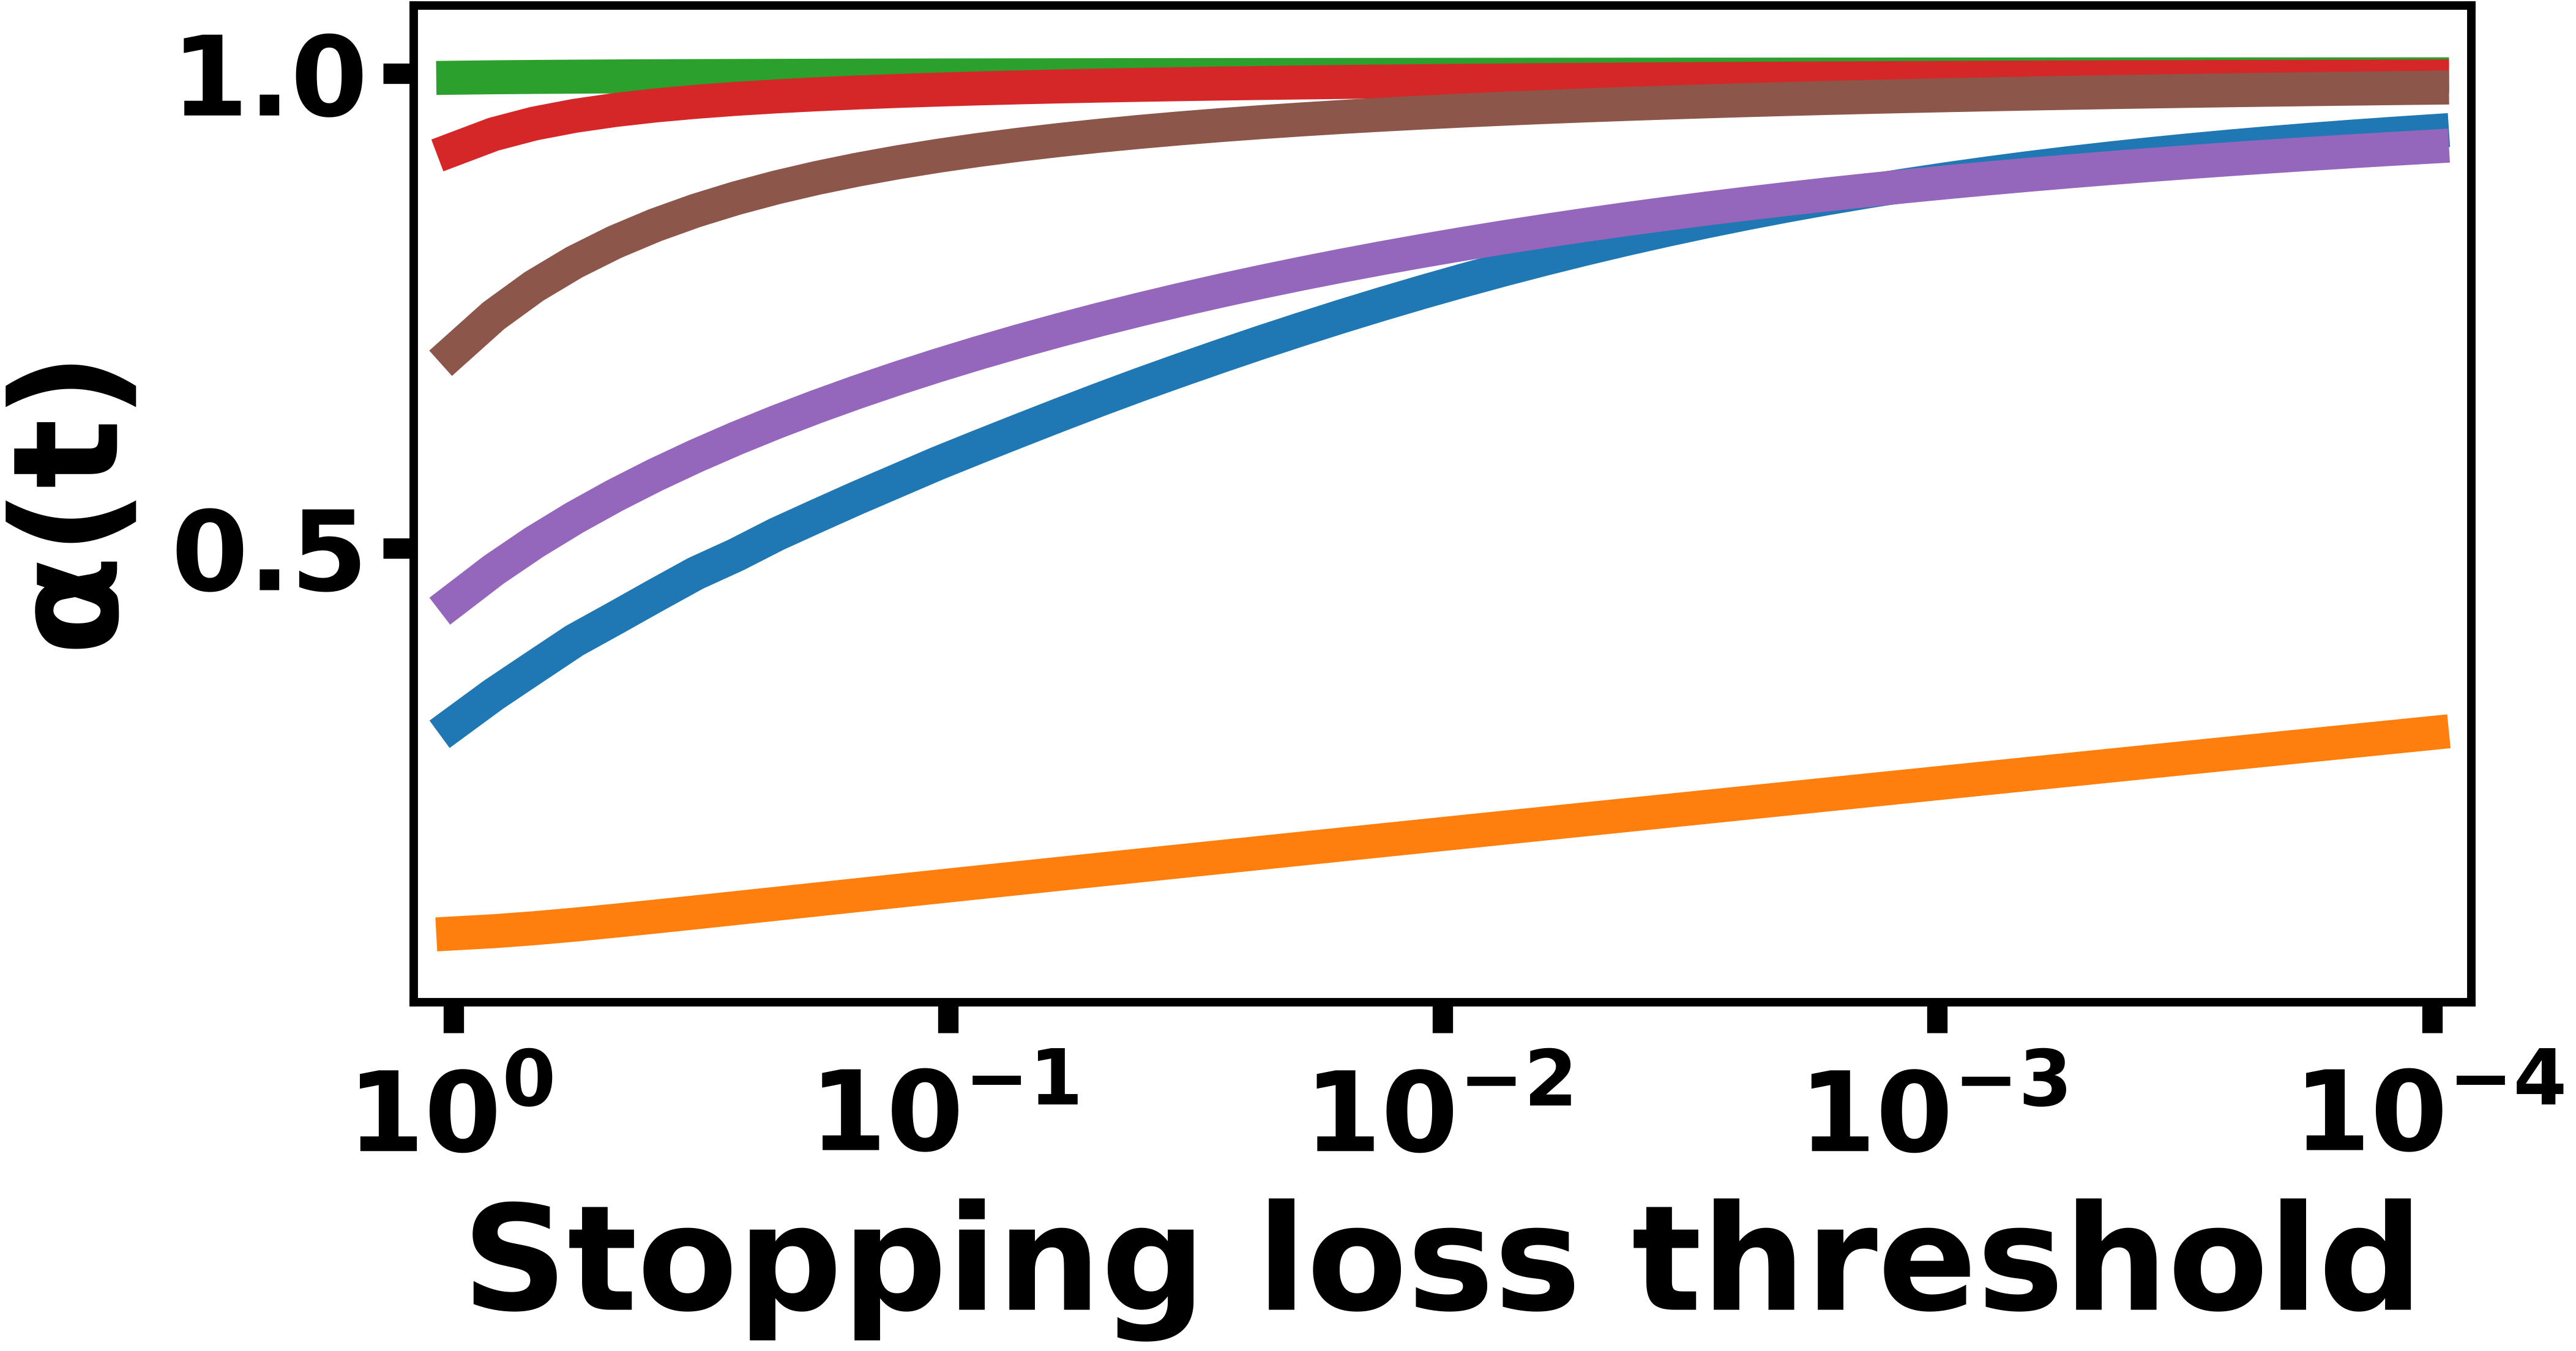

In [8]:
plot_stopping_curve_linear_x(r"$\bf{\alpha(t)}$",
                             lambda muov_at, muqk_at, alpha_at: alpha_at,
                             "alpha_stopping_loss_1.pdf")


In [9]:
# Theorem-1 setting used here: b = 1, d = M, with m = 5, n = 50, M = 20.
